In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Reading the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\sehri\Desktop\Project#2 _ Portfolio\data set for analysis\mymoviedb.csv")

df.index = df.index + 1

df.head(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
3,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


# Checking for Null values and handling them

In [3]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

## Total Number of Null values

In [4]:
df.isnull().sum().sum()

np.int64(80)

## Missing valules per column

In [5]:
missing_values = (df.isnull().sum()/df.shape[0])*100
missing_values_percentage = missing_values.round(2)
missing_values_percentage

Release_Date         0.00
Title                0.09
Overview             0.09
Popularity           0.10
Vote_Count           0.10
Vote_Average         0.10
Original_Language    0.10
Genre                0.11
Poster_Url           0.11
dtype: float64

In [6]:
missing_values_percentage_df = pd.DataFrame(missing_values_percentage, columns = ['Missing_values'])
missing_values_percentage_df  = missing_values_percentage_df.reset_index()
missing_values_percentage_df.columns = ['Column_Name', 'Percentage_Null_Values']
missing_values_percentage_df 

,Column_Name,Percentage_Null_Values
0,Release_Date,0.00
1,Title,0.09
2,Overview,0.09
3,Popularity,0.10
4,Vote_Count,0.10
5,Vote_Average,0.10
6,Original_Language,0.10
7,Genre,0.11
8,Poster_Url,0.11


## Dropping Null values from Label data

In [7]:
 df.dropna(subset = ['Title', 'Overview'])

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
3,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
4,11/24/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
5,12/22/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9833,10/15/1973,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9834,10/1/2020,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9835,5/6/2016,The Offering,When young and successful reporter Jamie finds...,13.355,94,5,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9836,3/31/2021,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [8]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

## Using Scikit-Learn to replace the numerical null values with mode values

In [9]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy = 'most_frequent')
cleaned_data = si.fit_transform(df)
df = pd.DataFrame(cleaned_data, columns  = ['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'])


### Checking for any remaining null values

In [10]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

# Checking for Duplicate entries 

In [11]:
df.duplicated().sum()

np.int64(0)

### There are no duplicated entries in our dataset

## Coverting the numeric columns i.e 'Popularity', 'Vote_Count', 'Vote_Average' back to int

In [12]:
for col in ['Popularity', 'Vote_Count', 'Vote_Average']:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print()


Unique values in Popularity:
[5083.954 3827.658 2618.087 ... 13.356 13.355 13.354]

Unique values in Vote_Count:
['8940' '1151' '122' ... '2395' '960' '1319']

Unique values in Vote_Average:
['8.3' '8.1' '6.3' '7.7' '7' '6.6' '6.8' '5.3' '7.2' '5.9' '7.3' '7.1'
 '5.1' '4.6' '6' '8.2' '5.4' '6.1' '8.4' '6.9' '5.8' '7.4' '7.8' '8' '6.2'
 '6.7' '7.6' '8.6' '4.8' '5.5' '7.9' '6.4' '7.5' '5.7' '2.2' '6.5' '0'
 '5.6' '5.2' '5' '8.5' '3.5' '4' '3.3' '4.7' '4.2' '4.3' '2' '4.1' '4.9'
 '8.7' '4.5' '9.1' '4.4' '3.6' 'Animation' '2.8' '3.9' '3.8' '9' '3' '3.1'
 '3.7' '3.4' '8.9' '2.9' '8.8' '3.2' '1.5' '9.2' '2.5' '1.8' '2.4' '2.6'
 '10']



In [13]:
cols_to_fix = ['Popularity', 'Vote_Count', 'Vote_Average']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce') 

df.dropna(subset=cols_to_fix, inplace=True)  
df[cols_to_fix] = df[cols_to_fix].astype(int)  


## Converting Release Date column to proper datetime data type

In [14]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors  = 'coerce')
df['Release_Date'].isna().sum()
df = df.dropna(subset=['Release_Date'])


### Adding a new column for Year of Release

In [15]:
df['Year_of_Release'] = df['Release_Date'].dt.year.astype(int)


# ******************** THE DATA HAS BEEN CLEANED ***************

In [16]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average,Year_of_Release
count,9827,9827.000000,9827.000000,9827.000000,9827.000000
mean,2006-09-23 11:05:51.317798144,39.825379,1392.801974,6.000102,2006.203623
min,1902-04-17 00:00:00,13.000000,0.000000,0.000000,1902.000000
25%,2000-10-18 00:00:00,16.000000,146.000000,5.000000,2000.000000
50%,2011-09-13 00:00:00,21.000000,444.000000,6.000000,2011.000000
75%,2017-11-22 00:00:00,35.000000,1376.000000,7.000000,2017.000000
max,2024-07-03 00:00:00,5083.000000,31077.000000,10.000000,2024.000000
std,NaN,108.874558,2611.208783,1.138800,15.685554


# Statistical Insights

## 1. Popularity and vote count are heavily right-skewed — a few movies dominate.

## 2. Vote average is more consistent, with most movies scoring between 5 and 7.

## Visualization

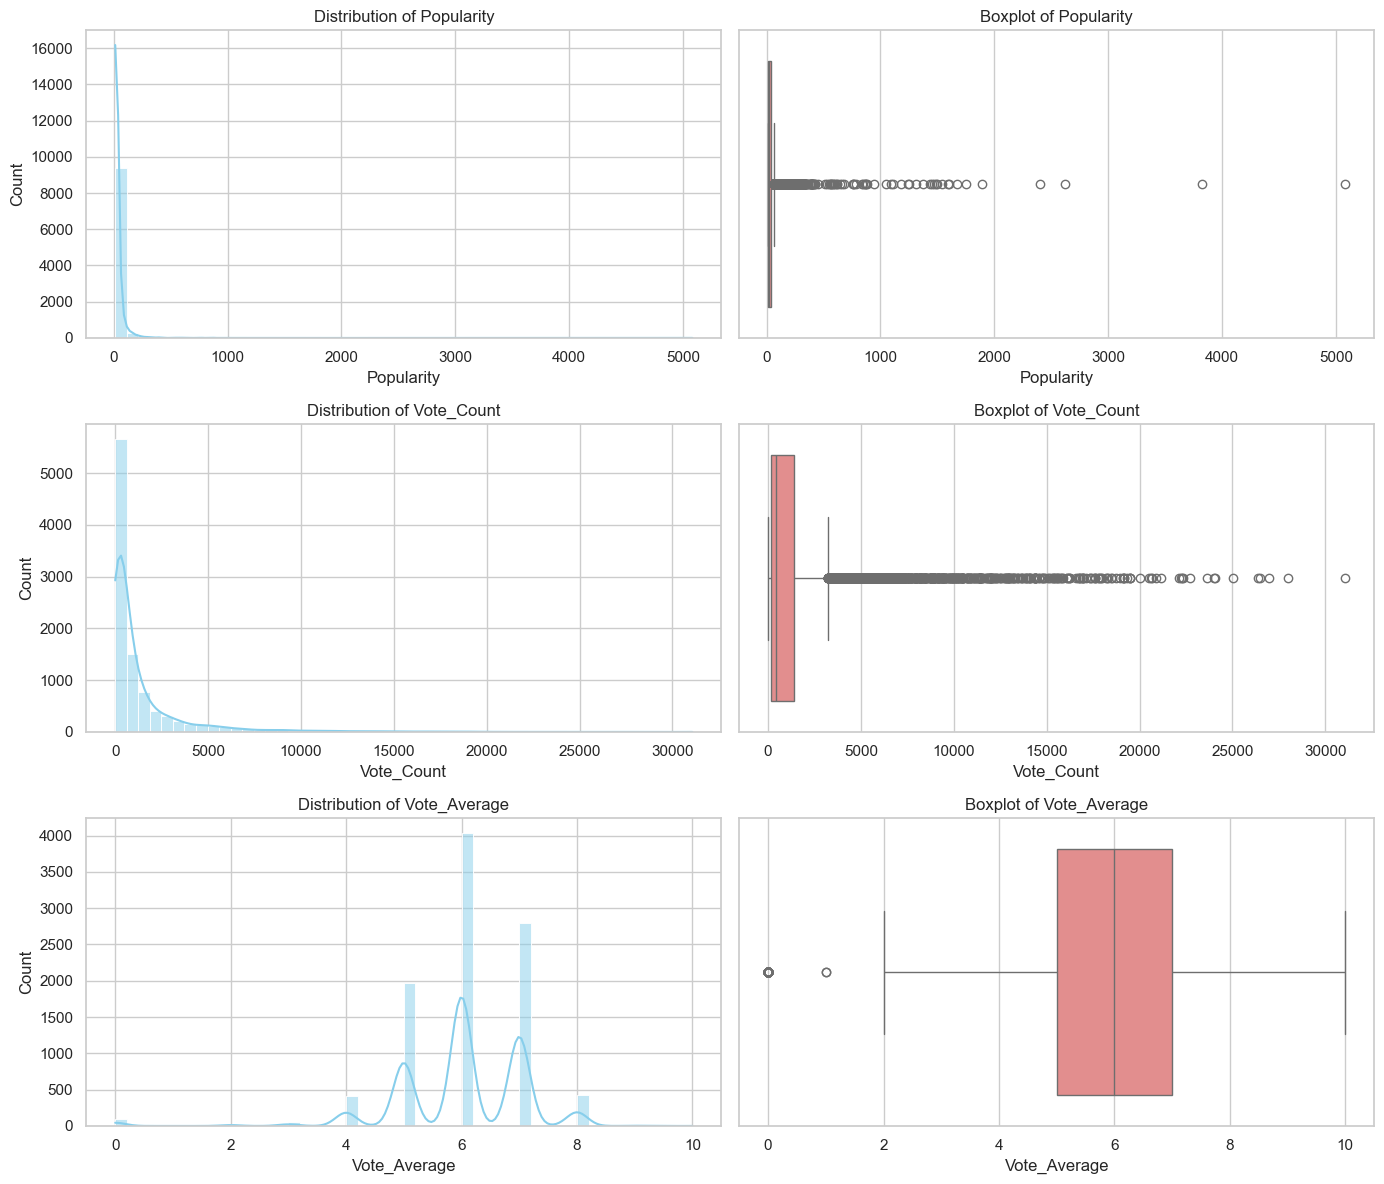

In [17]:

sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

columns = ['Popularity', 'Vote_Count', 'Vote_Average']

for i, col in enumerate(columns):
    sns.histplot(df[col], bins=50, ax=axes[i, 0], kde=True, color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [18]:
df.dtypes

Release_Date         datetime64[ns]
Title                        object
Overview                     object
Popularity                    int64
Vote_Count                    int64
Vote_Average                  int64
Original_Language            object
Genre                        object
Poster_Url                   object
Year_of_Release               int64
dtype: object

# Adding a label based grading column 

In [19]:
bins = [0,3,5,7,9,10]
labels = ['Unpopular', 'Below_Average', 'Average', 'Above_Average', 'Popular']

df['Popularity_Grade']  = pd.cut(df['Vote_Average'], bins = bins, labels = labels)

## Checking for and dropping null values in Popularity Grade column

In [20]:
df.isnull().sum()

Release_Date           0
Title                  0
Overview               0
Popularity             0
Vote_Count             0
Vote_Average           0
Original_Language      0
Genre                  0
Poster_Url             0
Year_of_Release        0
Popularity_Grade     100
dtype: int64

In [21]:
df = df.dropna(subset = ['Popularity_Grade'])

## Distribution of movie titles based on Grading

In [22]:
df['Popularity_Grade'].value_counts()

Popularity_Grade
Average          6824
Below_Average    2388
Above_Average     435
Unpopular          79
Popular             1
Name: count, dtype: int64

C:\Users\sehri\AppData\Local\Temp\ipykernel_6848\446658666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


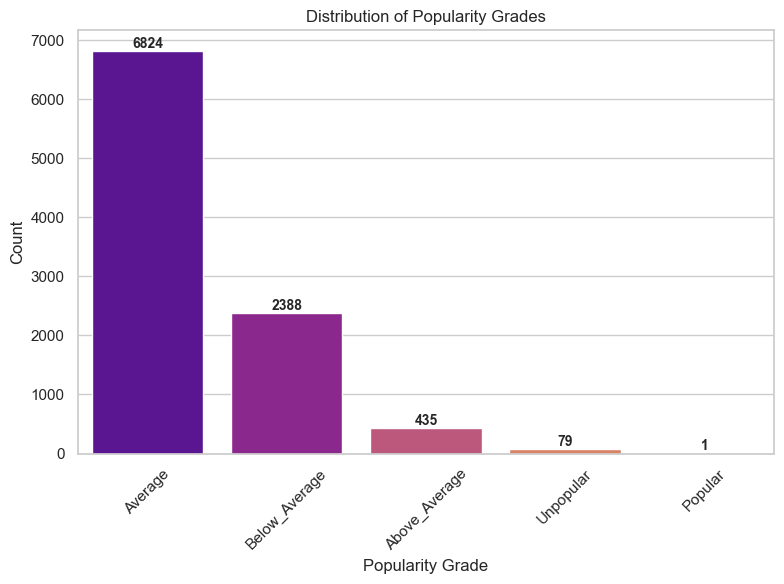

In [23]:

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df, 
    x='Popularity_Grade', 
    order=df['Popularity_Grade'].value_counts().index, 
    palette='plasma'
)


for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', 
                (p.get_x() + p.get_width() / 2.,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold')
    

plt.title('Distribution of Popularity Grades')
plt.xlabel('Popularity Grade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
df['Genre']

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9832                          Drama, Crime
9833                                Horror
9834             Mystery, Thriller, Horror
9835                 Music, Drama, History
9836           War, Drama, Science Fiction
Name: Genre, Length: 9727, dtype: object

# Splitting the genre column into multiple rows for each individual genre

In [31]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')
df['Genre'] = df['Genre'].astype('category')
df.index = df.index + 1

# ******* THE DATA HAS BEEN CLEANED and HANDLED APPROPRIATELY *******

# ******* Now we will use visualizations to get insights from the data *******

## Count of movies per individual Genre

C:\Users\sehri\AppData\Local\Temp\ipykernel_6848\3664968250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index,  palette='Set2')


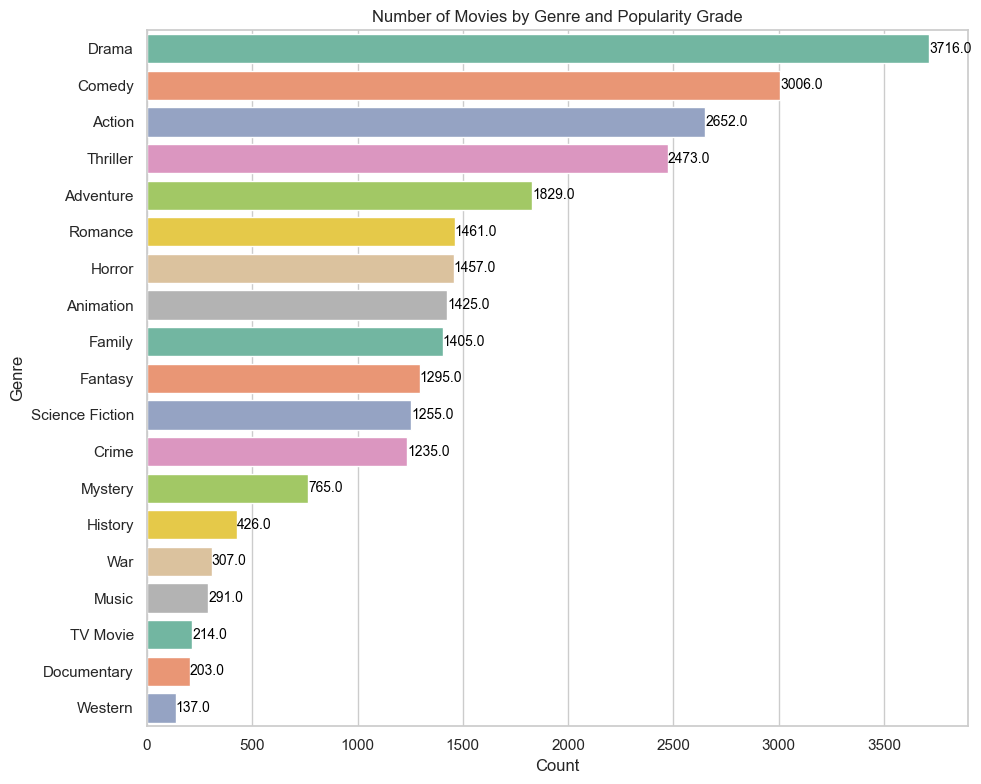

In [75]:

plt.figure(figsize=(10, 8))
ax = sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index,  palette='Set2')

for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width() + 0.2, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black')

plt.title('Number of Movies by Genre and Popularity Grade')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


# Average Vote per Genre

C:\Users\sehri\AppData\Local\Temp\ipykernel_6848\2304086504.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Genre', y='Vote_Average', data=df, estimator='mean', ci=None, palette='viridis')
C:\Users\sehri\AppData\Local\Temp\ipykernel_6848\2304086504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Genre', y='Vote_Average', data=df, estimator='mean', ci=None, palette='viridis')


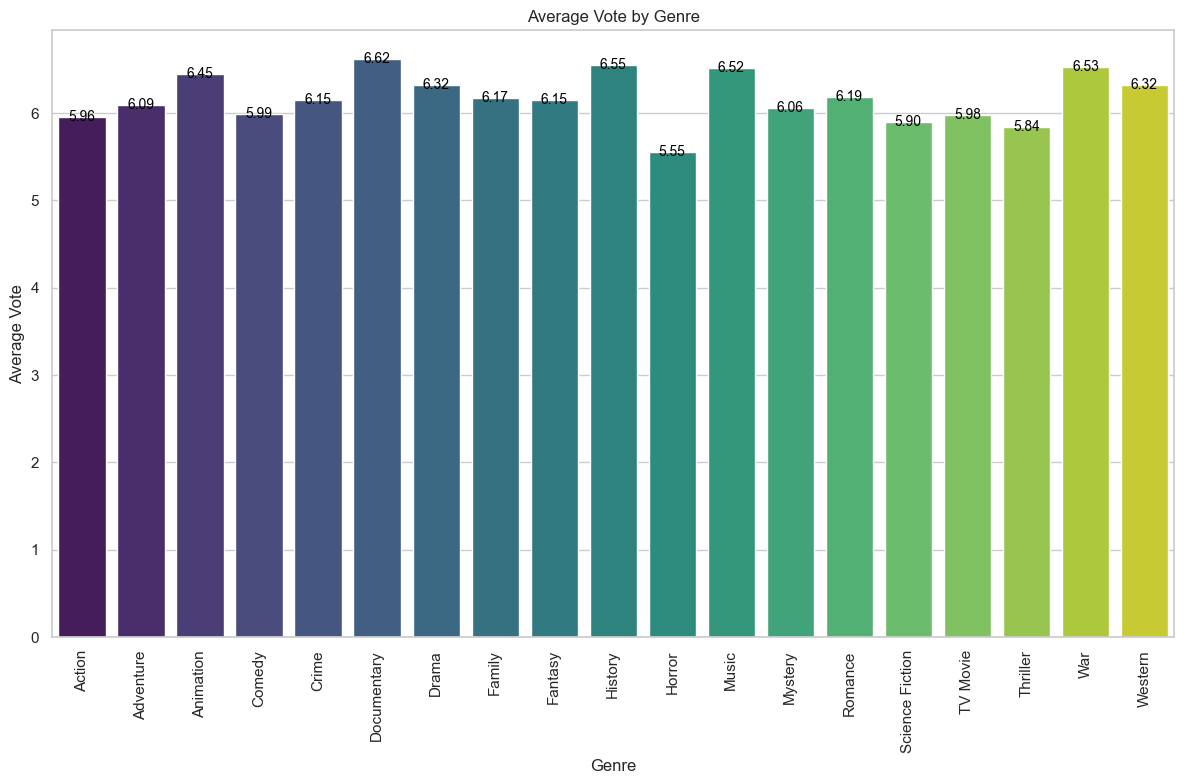

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Genre', y='Vote_Average', data=df, estimator='mean', ci=None, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                va='center', ha='center', fontsize=10, color='black')

plt.title('Average Vote by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Vote')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Genre Popularity trend over time

C:\Users\sehri\AppData\Local\Temp\ipykernel_6848\48990582.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_popularity = df.groupby(['Year_of_Release', 'Genre'])['Popularity'].mean().reset_index()


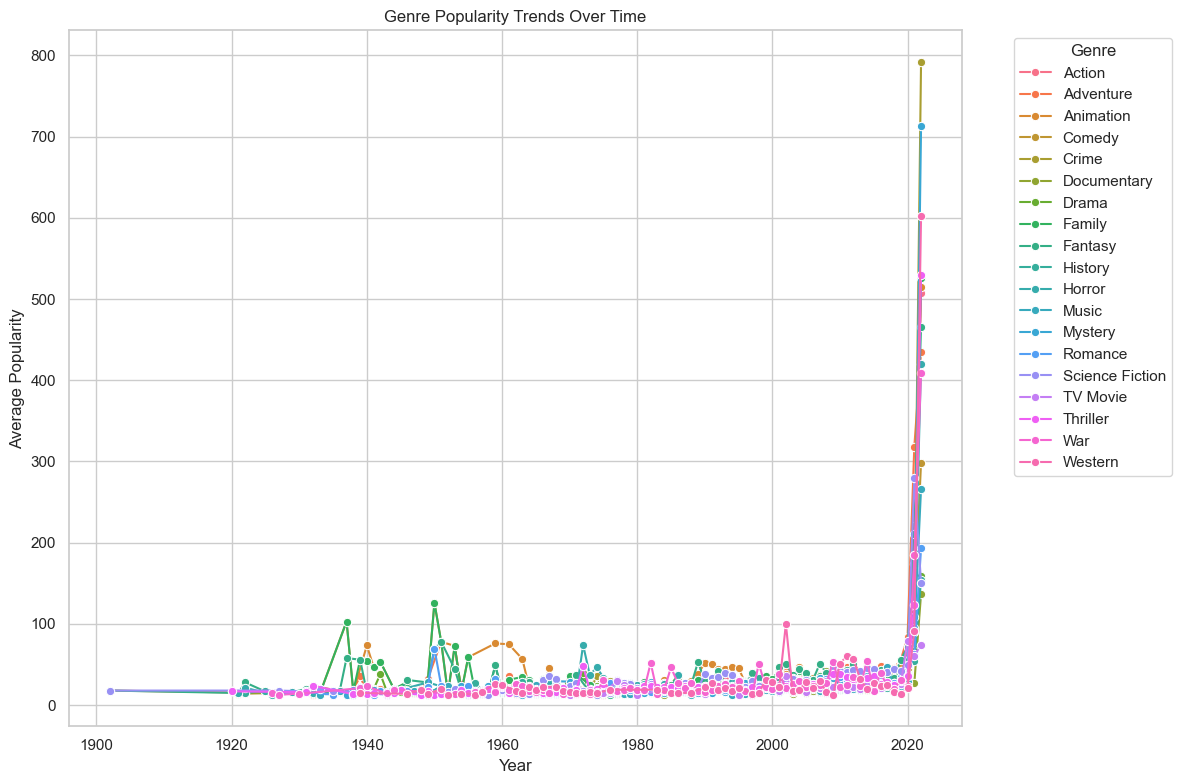

In [52]:

genre_popularity = df.groupby(['Year_of_Release', 'Genre'])['Popularity'].mean().reset_index()
plt.figure(figsize=(12, 8))

sns.lineplot(data=genre_popularity, x='Year_of_Release', y='Popularity', hue='Genre', marker='o')

plt.title('Genre Popularity Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Movies released per year Trend

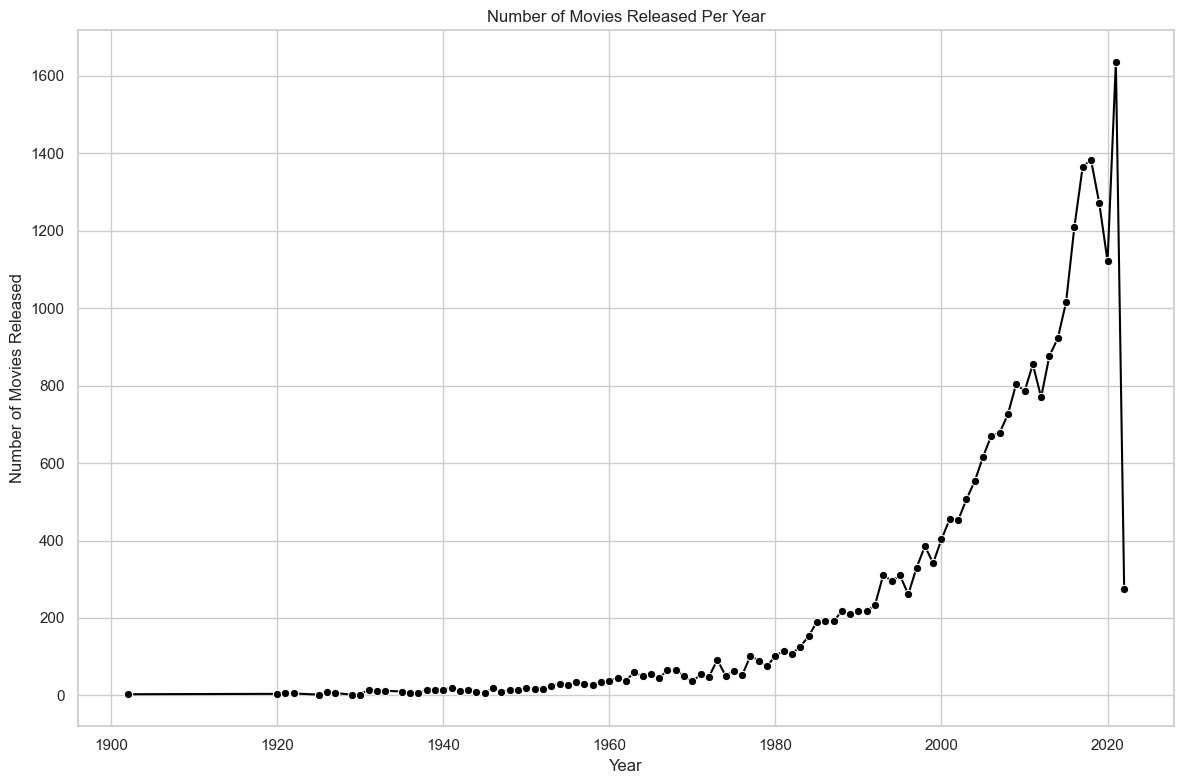

In [57]:
movies_per_year = df['Year_of_Release'].value_counts().sort_index()


plt.figure(figsize=(12, 8))


sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o', color = 'Black')

plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies Released')
plt.tight_layout()
plt.show()


# Distribution of Vote Average for the whole data set

<Axes: xlabel='Vote_Average', ylabel='Count'>

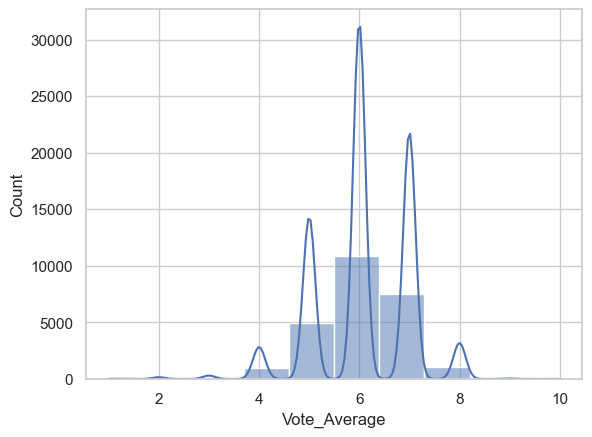

In [60]:
sns.histplot(df['Vote_Average'], bins=10, kde=True)

<Axes: xlabel='Popularity_Grade', ylabel='count'>

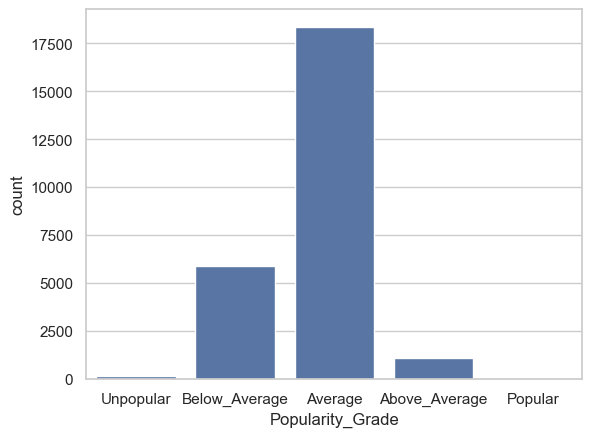

In [62]:
sns.countplot(x='Popularity_Grade', data=df)


###  1. Which genre has the most number of movies?


In [89]:
max_genre = df['Genre'].value_counts().idxmax()

print(f' The Genre with the highest number of movies is {max_genre}')


 The Genre with the highest number of movies is Drama


### 2. Which genre has the least number of movies?


In [87]:
min_genre = df['Genre'].value_counts().idxmin()

print(f' The Genre with the least number of movies is {min_genre}')

 The Genre with the least number of movies is Western


### 3. Year with the most number of movie released

In [80]:
most_movies_year = df['Year_of_Release'].value_counts().idxmax()
most_movies_count = df['Year_of_Release'].value_counts().max()

print(f"The year with the most movies released is {most_movies_year} with {most_movies_count} movies.")


The year with the most movies released is 2021 with 1636 movies.


### 4. Which genre has the highest average vote count? 

In [93]:
top_genre = df.groupby('Genre', observed=True)['Vote_Count'].mean().idxmax()

print(f"The genre with the highest average vote count is {top_genre}")




The genre with the highest average vote count is Adventure


### 5. Which genre has the lowest average vote count? 

In [95]:
btm_genre = df.groupby('Genre', observed=True)['Vote_Count'].mean().idxmin()

print(f"The genre with the lowest average vote count is {btm_genre}")




The genre with the lowest average vote count is Documentary


### 6. Most Popular Movie?

In [126]:
top_movie_idx = df[df['Popularity_Grade'] == 'Popular']['Popularity'].idxmax()
top_movie = df.loc[top_movie_idx]
print(f"The most popular movie is:\n{top_movie[['Title', 'Popularity', 'Vote_Average', 'Vote_Count', 'Popularity_Grade']]}")



The most popular movie is:
                           Title  Popularity  Vote_Average  Vote_Count  \
9403  Kung Fu Master Huo Yuanjia          13            10           1   
9403  Kung Fu Master Huo Yuanjia          13            10           1   

     Popularity_Grade  
9403          Popular  
9403          Popular  


### 7. Least Popular Movie?

In [123]:
btm_movie_idx = df[df['Popularity_Grade'] == 'Unpopular']['Popularity'].idxmin()
btm_movie = df.loc[btm_movie_idx]
print(f"The least popular movie is:\n{btm_movie[['Title', 'Popularity', 'Vote_Average', 'Vote_Count', 'Popularity_Grade']]}")


The least popular movie is:
                           Title  Popularity  Vote_Average  Vote_Count  \
9237  Mega Shark vs. Crocosaurus          13             3         135   
9237  Mega Shark vs. Crocosaurus          13             3         135   
9237  Mega Shark vs. Crocosaurus          13             3         135   

     Popularity_Grade  
9237        Unpopular  
9237        Unpopular  
9237        Unpopular  
